# 03 Complaint Gap Analysis - 修复完整版

**已修复的内容：**
1. ✅ Complaint Gap 识别
2. ✅ 机器学习分类（Random Forest）
3. ✅ 回归分析
4. ✅ 优先级评分
5. ✅ 导出结果

**运行前确保：**
- 你已经运行完 01 和 02 notebooks
- `finaldata/processed_data/philly_integrated_data.shp` 存在

## 0. 导入库

In [1]:
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("✅ 库已导入")

✅ 库已导入


## 1. 加载数据

In [2]:
# 设置路径
DATA_DIR = "./finaldata"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed_data")
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 加载整合后的数据
gdf = gpd.read_file(os.path.join(PROCESSED_DIR, "philly_integrated_data.shp"))

print(f"数据: {len(gdf)} block groups")
print(f"字段: {len(gdf.columns)}")
print("\n所有列名:")
for i, col in enumerate(gdf.columns):
    print(f"  {i}: {col}")

数据: 1338 block groups
字段: 61

所有列名:
  0: STATEFP
  1: COUNTYFP
  2: TRACTCE
  3: BLKGRPCE
  4: GEOID
  5: NAMELSAD
  6: MTFCC
  7: FUNCSTAT
  8: ALAND
  9: AWATER
  10: INTPTLAT
  11: INTPTLON
  12: viirs_2021
  13: viirs_2022
  14: viirs_20_1
  15: viirs_20_2
  16: viirs_20_3
  17: viirs_20_4
  18: viirs_20_5
  19: viirs_20_6
  20: viirs_20_7
  21: viirs_20_8
  22: viirs_20_9
  23: viirs_2010
  24: viirs_2011
  25: viirs_2023
  26: viirs_2012
  27: viirs_2013
  28: viirs_2014
  29: viirs_2015
  30: viirs_2016
  31: viirs_2017
  32: viirs_2018
  33: viirs_2019
  34: viirs_2020
  35: viirs_2024
  36: viirs_2025
  37: viirs_2026
  38: viirs_2027
  39: viirs_2028
  40: viirs_2029
  41: viirs_2030
  42: viirs_2031
  43: viirs_2032
  44: viirs_2033
  45: viirs_2034
  46: viirs_2035
  47: viirs_2036
  48: viirs_2037
  49: viirs_2038
  50: viirs_2039
  51: viirs_2040
  52: viirs_all_
  53: viirs_chan
  54: viirs_pct_
  55: TRACT_ID
  56: population
  57: median_inc
  58: poverty_ra
  59: no_v

## 2. 数据清理和列名识别

In [3]:
# ============================================================================
# Cell 2: 加载数据
# ============================================================================

import os
import pandas as pd
import geopandas as gpd

# 设置路径
DATA_DIR = "./finaldata"
PROCESSED_DIR = os.path.join(DATA_DIR, "processed_data")
os.makedirs(PROCESSED_DIR, exist_ok=True)

# 加载同学的完整数据
gdf = gpd.read_file(os.path.join(PROCESSED_DIR, "philly_lighting_equity_final.shp"))

print(f"数据: {len(gdf)} block groups")
print(f"字段: {len(gdf.columns)}")
print("\n所有列名:")
for i, col in enumerate(gdf.columns):
    print(f"  {i}: {col}")

数据: 1338 block groups
字段: 73

所有列名:
  0: STATEFP
  1: COUNTYFP
  2: TRACTCE
  3: BLKGRPCE
  4: GEOID
  5: NAMELSAD
  6: MTFCC
  7: FUNCSTAT
  8: ALAND
  9: AWATER
  10: INTPTLAT
  11: INTPTLON
  12: viirs_2022
  13: viirs_20_1
  14: viirs_20_2
  15: viirs_20_3
  16: viirs_20_4
  17: viirs_20_5
  18: viirs_20_6
  19: viirs_20_7
  20: viirs_20_8
  21: viirs_20_9
  22: viirs_2010
  23: viirs_2011
  24: viirs_2023
  25: viirs_2012
  26: viirs_2013
  27: viirs_2014
  28: viirs_2015
  29: viirs_2016
  30: viirs_2017
  31: viirs_2018
  32: viirs_2019
  33: viirs_2020
  34: viirs_2021
  35: viirs_2024
  36: viirs_2025
  37: viirs_2026
  38: viirs_2027
  39: viirs_2028
  40: viirs_2029
  41: viirs_2030
  42: viirs_2031
  43: viirs_2032
  44: viirs_2033
  45: viirs_2034
  46: viirs_2035
  47: viirs_2036
  48: viirs_2037
  49: viirs_2038
  50: viirs_2039
  51: viirs_all_
  52: viirs_chan
  53: viirs_pct_
  54: median_inc
  55: TRACT_GEOI
  56: median_i_1
  57: crime_2025
  58: streetligh
  59: st

In [6]:
# 在Cell 2后面加一个新的cell运行这个
print("关键列搜索：")
print("\n包含 '311' 的列：")
print([c for c in gdf.columns if '311' in str(c).lower()])

print("\n包含 'crime' 的列：")
print([c for c in gdf.columns if 'crime' in str(c).lower()])

print("\n包含 'streetlight' 的列：")
print([c for c in gdf.columns if 'street' in str(c).lower()])

print("\n包含 'income' 的列：")
print([c for c in gdf.columns if 'income' in str(c).lower() or 'inc' in str(c).lower()])

print("\n包含 'poverty' 的列：")
print([c for c in gdf.columns if 'pov' in str(c).lower()])

关键列搜索：

包含 '311' 的列：
['high_311']

包含 'crime' 的列：
['crime_2025', 'crime_per_', 'high_crime']

包含 'streetlight' 的列：
['streetligh', 'streetli_1', 'streetli_2', 'streetli_3', 'streetli_4', 'streetli_5']

包含 'income' 的列：
['median_inc']

包含 'poverty' 的列：
[]


In [9]:
# 在Cell 2后面加一个新cell
import os

print("当前工作目录:", os.getcwd())
print("\n检查文件是否存在:")

file_path = os.path.join(PROCESSED_DIR, "philly_lighting_equity_final.shp")
print(f"完整路径: {file_path}")
print(f"文件存在: {os.path.exists(file_path)}")

if os.path.exists(file_path):
    print(f"文件大小: {os.path.getsize(file_path) / 1024:.0f} KB")

当前工作目录: D:\pen\MUSA5500GeospatialDataScienceInPython\final

检查文件是否存在:
完整路径: ./finaldata\processed_data\philly_lighting_equity_final.shp
文件存在: True
文件大小: 898 KB


## 3. 描述性统计

In [11]:
# ============================================================================
# Cell 3: 数据清理和列名识别（最终修复版）
# ============================================================================

import pandas as pd
import numpy as np

# 自动识别列名
def find_col(keywords, columns):
    for keyword in keywords:
        matches = [c for c in columns if keyword.lower() in str(c).lower()]
        if matches:
            return matches[0]
    return None

# 列名识别（根据你的实际数据）
viirs_col = find_col(['viirs_2024', 'viirs_mean'], gdf.columns)
report_311_col = find_col(['streetli_5', 'streetli'], gdf.columns)
income_col = find_col(['median_i_1', 'median_inc'], gdf.columns)  # ⭐ 修复：优先找 median_i_1
crime_rate_col = find_col(['crime_per_', 'crime_2025'], gdf.columns)
poverty_col = find_col(['poverty', 'pov'], gdf.columns)

print("="*70)
print("列名识别结果")
print("="*70)
print(f"VIIRS亮度: {viirs_col}")
print(f"311报修: {report_311_col}")
print(f"收入: {income_col}")
print(f"犯罪率: {crime_rate_col}")
print(f"贫困率: {poverty_col if poverty_col else '❌ 未找到 (可选)'}")

# 验证数据质量
print("\n数据质量检查:")
if income_col:
    non_null = gdf[income_col].notna().sum()
    print(f"  {income_col}: {non_null} 个非空值")
if crime_rate_col:
    non_null = gdf[crime_rate_col].notna().sum()
    print(f"  {crime_rate_col}: {non_null} 个非空值")

# 检查必需列
required_cols = [viirs_col, report_311_col, income_col, crime_rate_col]
if all(required_cols):
    print("\n✅ 所有核心列都找到了！")
    
    # 创建收入分组
    print("\n📝 创建收入分组...")
    income_values = gdf[income_col].dropna()
    
    if len(income_values) > 0:
        p25 = income_values.quantile(0.25)
        p50 = income_values.quantile(0.50)
        p75 = income_values.quantile(0.75)
        
        print(f"收入四分位数: {p25:.0f}, {p50:.0f}, {p75:.0f}")
        
        def assign_income_group(value):
            if pd.isna(value):
                return None
            if value <= p25:
                return 'Low'
            elif value <= p50:
                return 'Mid-Low'
            elif value <= p75:
                return 'Mid-High'
            else:
                return 'High'
        
        gdf['income_group'] = gdf[income_col].apply(assign_income_group)
        income_group_col = 'income_group'
        print(f"✅ 收入分组创建完成")
        
        # 显示分组统计
        print("\n收入分组统计:")
        print(gdf['income_group'].value_counts().sort_index())
    else:
        print(f"❌ {income_col} 列没有有效数据！")
    
    # 清理数据
    key_cols = [viirs_col, report_311_col, income_col, crime_rate_col]
    gdf_clean = gdf.dropna(subset=key_cols).copy()
    print(f"\n清理后: {len(gdf_clean)} block groups")
    
    if len(gdf_clean) == 0:
        print("\n⚠️ 警告：清理后没有数据！检查各列的非空值数量")
    
else:
    print("\n❌ 数据不完整")

列名识别结果
VIIRS亮度: viirs_2024
311报修: streetli_5
收入: median_i_1
犯罪率: crime_per_
贫困率: ❌ 未找到 (可选)

数据质量检查:
  median_i_1: 1283 个非空值
  crime_per_: 1338 个非空值

✅ 所有核心列都找到了！

📝 创建收入分组...
收入四分位数: 38713, 56641, 78871
✅ 收入分组创建完成

收入分组统计:
income_group
High        320
Low         322
Mid-High    321
Mid-Low     320
Name: count, dtype: int64

清理后: 1283 block groups


## 4. Complaint Gap 散点图

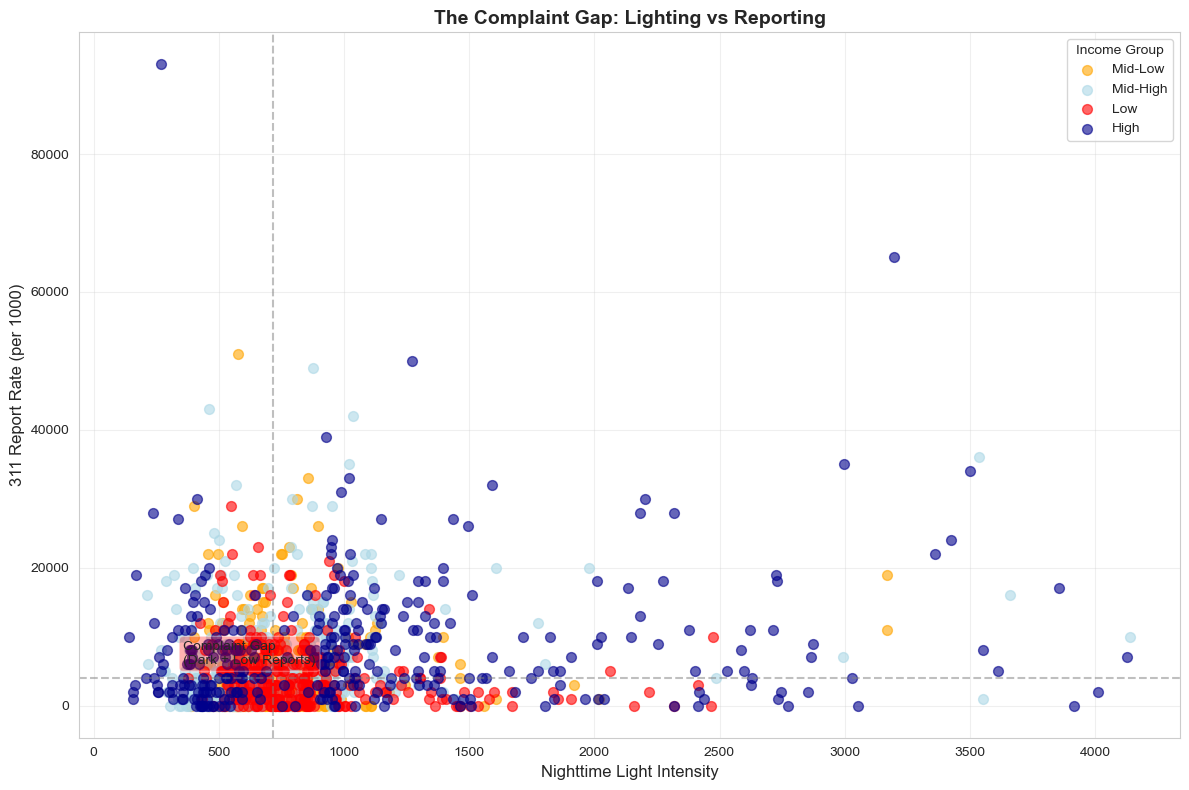


✅ 保存: complaint_gap_scatter.png


In [12]:
fig, ax = plt.subplots(figsize=(12, 8))

colors = {'Low': 'red', 'Mid-Low': 'orange', 'Mid-High': 'lightblue', 'High': 'darkblue'}

if income_group_col:
    for group in gdf_clean[income_group_col].unique():
        if pd.notna(group):
            subset = gdf_clean[gdf_clean[income_group_col] == group]
            ax.scatter(subset[viirs_col], subset[report_311_col], 
                      c=colors.get(group, 'gray'), label=group, alpha=0.6, s=50)
else:
    ax.scatter(gdf_clean[viirs_col], gdf_clean[report_311_col], alpha=0.6, s=50)

ax.set_xlabel('Nighttime Light Intensity', fontsize=12)
ax.set_ylabel('311 Report Rate (per 1000)', fontsize=12)
ax.set_title('The Complaint Gap: Lighting vs Reporting', fontsize=14, fontweight='bold')
if income_group_col:
    ax.legend(title='Income Group')
ax.grid(alpha=0.3)

viirs_median = gdf_clean[viirs_col].median()
report_median = gdf_clean[report_311_col].median()
ax.axvline(viirs_median, color='gray', linestyle='--', alpha=0.5)
ax.axhline(report_median, color='gray', linestyle='--', alpha=0.5)

ax.text(viirs_median*0.5, report_median*1.5, 'Complaint Gap\n(Dark + Low Reports)', 
        fontsize=10, bbox=dict(boxstyle='round', facecolor='red', alpha=0.3))

plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'complaint_gap_scatter.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ 保存: complaint_gap_scatter.png")

## 5. 识别 Complaint Gap ⭐ [新增]

In [13]:
# 定义Complaint Gap标准
viirs_threshold = gdf_clean[viirs_col].quantile(0.33)  # 最暗的1/3
report_threshold = gdf_clean[report_311_col].quantile(0.33)  # 报修最少的1/3
income_threshold = gdf_clean[income_col].median()  # 低于中位数收入

gdf_clean['is_gap'] = (
    (gdf_clean[viirs_col] < viirs_threshold) & 
    (gdf_clean[report_311_col] < report_threshold) &
    (gdf_clean[income_col] < income_threshold)
)

gap_count = gdf_clean['is_gap'].sum()
print(f"✅ Complaint Gap区域: {gap_count} ({gap_count/len(gdf_clean)*100:.1f}%)")

print("\nGap vs Non-Gap比较:")
comparison = gdf_clean.groupby('is_gap')[[viirs_col, report_311_col, income_col, crime_rate_col]].mean()
print(comparison)

# t检验
gap_areas = gdf_clean[gdf_clean['is_gap']]
non_gap = gdf_clean[~gdf_clean['is_gap']]

print("\nt-test结果:")
for var in [viirs_col, crime_rate_col, income_col]:
    t, p = stats.ttest_ind(gap_areas[var].dropna(), non_gap[var].dropna())
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {var}: t={t:.2f}, p={p:.4f} {sig}")

✅ Complaint Gap区域: 62 (4.8%)

Gap vs Non-Gap比较:
        viirs_2024   streetli_5    median_i_1    crime_per_
is_gap                                                     
False   874.641125  6624.897625  61951.292383  29093.366093
True    542.160049   500.000000  43248.548387  19145.161290

t-test结果:
  viirs_2024: t=-4.79, p=0.0000 ***
  crime_per_: t=-2.83, p=0.0048 **
  median_i_1: t=-4.88, p=0.0000 ***


## 6. 机器学习分类 ⭐ [新增]

找到poverty列: None
找到vehicle列: None

机器学习数据: 1283 样本, 3 特征
Gap区域: 62 (4.8%)

✅ Random Forest分类结果:
              precision    recall  f1-score   support

     Non-Gap       0.96      0.99      0.97       366
         Gap       0.38      0.16      0.22        19

    accuracy                           0.95       385
   macro avg       0.67      0.57      0.60       385
weighted avg       0.93      0.95      0.93       385


Feature Importance:
      feature  importance
1  viirs_2024    0.422360
0  median_i_1    0.357632
2  crime_per_    0.220008


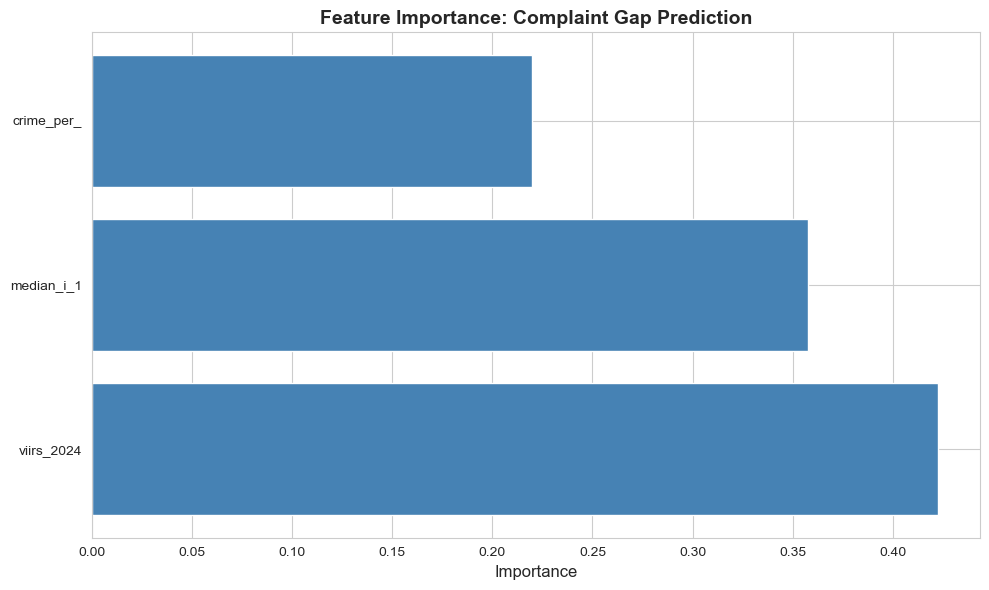


✅ 保存: feature_importance.png


In [14]:
# 找poverty和vehicle列
poverty_col = find_col(['poverty', 'pov_rate'], gdf_clean.columns)
vehicle_col = find_col(['no_vehicle', 'no_veh'], gdf_clean.columns)

print(f"找到poverty列: {poverty_col}")
print(f"找到vehicle列: {vehicle_col}")

features = [income_col, poverty_col, vehicle_col, viirs_col, crime_rate_col]
features = [f for f in features if f is not None]  # 移除None

ml_data = gdf_clean.dropna(subset=features + ['is_gap']).copy()

X = ml_data[features]
y = ml_data['is_gap']

print(f"\n机器学习数据: {len(ml_data)} 样本, {len(features)} 特征")
print(f"Gap区域: {y.sum()} ({y.sum()/len(y)*100:.1f}%)")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("\n✅ Random Forest分类结果:")
print(classification_report(y_test, y_pred, target_names=['Non-Gap', 'Gap']))

# Feature importance
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(feat_imp)

# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='steelblue')
ax.set_xlabel('Importance', fontsize=12)
ax.set_title('Feature Importance: Complaint Gap Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'feature_importance.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ 保存: feature_importance.png")

# 保存模型准确率供后续使用
rf_accuracy = rf.score(X_test, y_test)

## 7. 回归分析 ⭐ [新增]

回归数据: 1283 样本

✅ 回归分析（Crime Rate）:
R² = 0.115

标准化系数:
      Feature  Coefficient
2  median_i_1 -8369.951846
0  viirs_2024  5908.819292
1  streetli_5  2827.331714


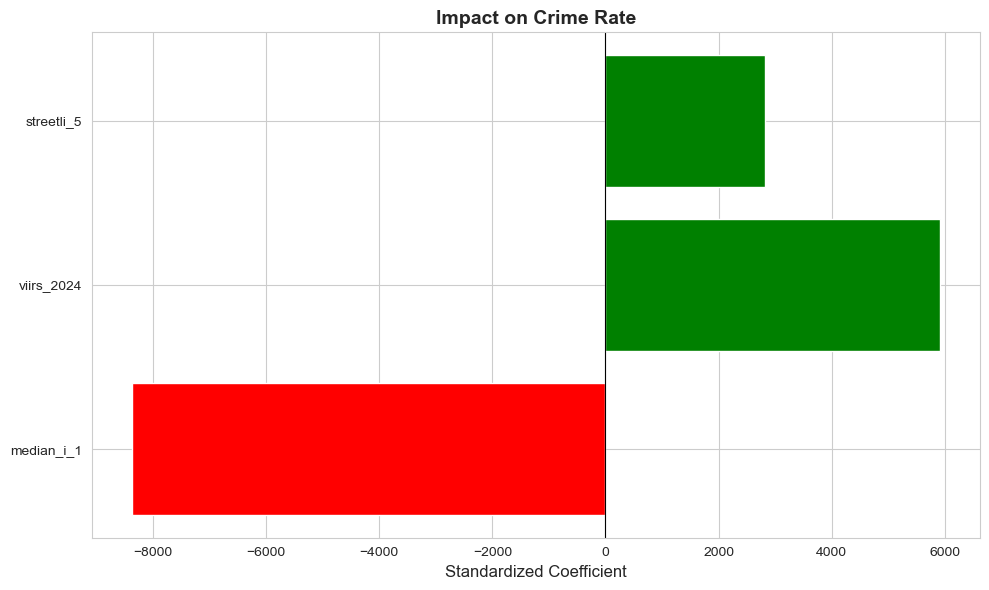


✅ 保存: regression_coef.png


In [15]:
# 回归分析：犯罪率 ~ 亮度 + 报修 + 收入 + 贫困
reg_features = [viirs_col, report_311_col, income_col, poverty_col]
reg_features = [f for f in reg_features if f is not None]

reg_data = gdf_clean.dropna(subset=reg_features + [crime_rate_col]).copy()

X_reg = reg_data[reg_features]
y_reg = reg_data[crime_rate_col]

print(f"回归数据: {len(reg_data)} 样本")

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reg)

# 线性回归
lr = LinearRegression()
lr.fit(X_scaled, y_reg)

r2 = lr.score(X_scaled, y_reg)

coef_df = pd.DataFrame({
    'Feature': reg_features,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\n✅ 回归分析（Crime Rate）:")
print(f"R² = {r2:.3f}")
print("\n标准化系数:")
print(coef_df)

# 可视化
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient', fontsize=12)
ax.set_title('Impact on Crime Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'regression_coef.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ 保存: regression_coef.png")

## 8. 优先级评分 ⭐ [新增]

✅ 优先级分布:
pri_level
Low            0
Medium        33
High        1115
Critical     135
Name: count, dtype: int64

Top 20优先维修区域:
             GEOID  priority   viirs_2024  crime_per_  median_i_1
1223  421010178002  0.831380   840.500000    201000.0     32009.0
1200  421010177011  0.824836   845.750000    178000.0     36694.0
1205  421010178004  0.821916   877.000000    195000.0     32009.0
1267  421010349001  0.817639   550.933333    186000.0     59563.0
226   421010147002  0.812176  1853.333333    253000.0     18041.0
501   421010379003  0.810063  1115.250000    343000.0     69198.0
862   421010177012  0.809450   898.500000    175000.0     36694.0
753   421010241001  0.799919   696.500000     90000.0     16042.0
707   421010282003  0.799854   902.714286    126000.0     20674.0
1201  421010177022  0.796721   861.500000    132000.0     28750.0
39    421010245001  0.795513   578.142857     69000.0     19589.0
528   421010066003  0.792183   672.333333    103000.0     32946.0
487   42101017

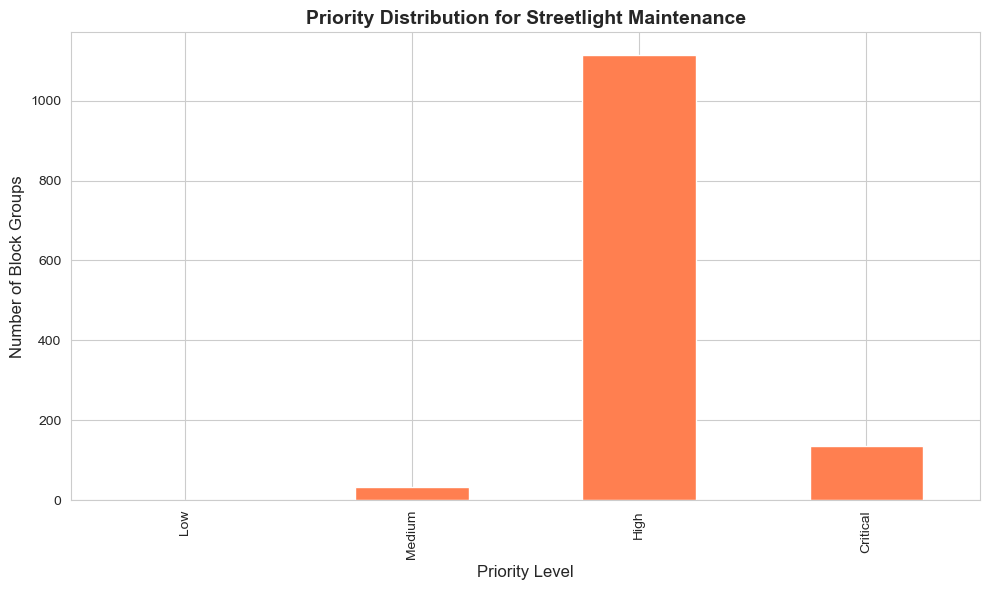


✅ 保存: priority_distribution.png


In [16]:
# 标准化各项分数（0-1）
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

gdf_clean['dark_score'] = 1 - normalize(gdf_clean[viirs_col])  # 越暗分数越高
gdf_clean['low_report'] = 1 - normalize(gdf_clean[report_311_col])  # 报修越少分数越高
gdf_clean['high_crime'] = normalize(gdf_clean[crime_rate_col])  # 犯罪越高分数越高
gdf_clean['low_income'] = 1 - normalize(gdf_clean[income_col])  # 收入越低分数越高

# 加权计算优先级
gdf_clean['priority'] = (
    gdf_clean['dark_score'] * 0.3 +
    gdf_clean['low_report'] * 0.3 +
    gdf_clean['high_crime'] * 0.2 +
    gdf_clean['low_income'] * 0.2
)

# 分级
gdf_clean['pri_level'] = pd.cut(
    gdf_clean['priority'],
    bins=[0, 0.25, 0.5, 0.75, 1.0],
    labels=['Low', 'Medium', 'High', 'Critical']
)

print("✅ 优先级分布:")
print(gdf_clean['pri_level'].value_counts().sort_index())

print("\nTop 20优先维修区域:")
top20 = gdf_clean.nlargest(20, 'priority')[['GEOID', 'priority', viirs_col, crime_rate_col, income_col]]
print(top20)

# 可视化优先级分布
fig, ax = plt.subplots(figsize=(10, 6))
gdf_clean['pri_level'].value_counts().sort_index().plot(kind='bar', ax=ax, color='coral')
ax.set_xlabel('Priority Level', fontsize=12)
ax.set_ylabel('Number of Block Groups', fontsize=12)
ax.set_title('Priority Distribution for Streetlight Maintenance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, 'priority_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
print("\n✅ 保存: priority_distribution.png")

## 9. 导出结果 ⭐ [新增]

In [17]:
# 1) 完整分析结果
gdf_clean.to_file(os.path.join(PROCESSED_DIR, "analysis_results.shp"))
print("✅ 保存: analysis_results.shp")

# 2) 高优先级区域
high_pri = gdf_clean[gdf_clean['pri_level'].isin(['High', 'Critical'])]
high_pri.to_file(os.path.join(PROCESSED_DIR, "priority_areas.shp"))
print(f"✅ 保存: priority_areas.shp ({len(high_pri)} BGs)")

# 3) Complaint Gap区域
gap_areas_gdf = gdf_clean[gdf_clean['is_gap']]
gap_areas_gdf.to_file(os.path.join(PROCESSED_DIR, "complaint_gap_areas.shp"))
print(f"✅ 保存: complaint_gap_areas.shp ({len(gap_areas_gdf)} BGs)")

# 4) 分析摘要
with open(os.path.join(PROCESSED_DIR, "analysis_summary.txt"), 'w', encoding='utf-8') as f:
    f.write("="*60 + "\n")
    f.write("费城路灯公平性分析 - 结果摘要\n")
    f.write("="*60 + "\n\n")
    
    f.write(f"总Block Groups: {len(gdf_clean)}\n\n")
    
    f.write(f"Complaint Gap区域: {gap_count} ({gap_count/len(gdf_clean)*100:.1f}%)\n")
    f.write(f"高优先级区域: {len(high_pri)} ({len(high_pri)/len(gdf_clean)*100:.1f}%)\n\n")
    
    f.write(f"机器学习准确率: {rf_accuracy:.3f}\n")
    f.write(f"回归模型 R²: {r2:.3f}\n\n")
    
    f.write("优先级分布:\n")
    for level in ['Low', 'Medium', 'High', 'Critical']:
        count = (gdf_clean['pri_level'] == level).sum()
        f.write(f"  {level}: {count} ({count/len(gdf_clean)*100:.1f}%)\n")
    
    f.write("\n" + "="*60 + "\n")
    f.write("生成的文件:\n")
    f.write("  - analysis_results.shp (完整结果)\n")
    f.write("  - priority_areas.shp (高优先级区域)\n")
    f.write("  - complaint_gap_areas.shp (Complaint Gap区域)\n")
    f.write("  - complaint_gap_scatter.png\n")
    f.write("  - feature_importance.png\n")
    f.write("  - regression_coef.png\n")
    f.write("  - priority_distribution.png\n")

print("✅ 保存: analysis_summary.txt")

print("\n" + "="*60)
print("🎉 完成！所有分析已完成并保存")
print("="*60)

✅ 保存: analysis_results.shp
✅ 保存: priority_areas.shp (1250 BGs)
✅ 保存: complaint_gap_areas.shp (62 BGs)
✅ 保存: analysis_summary.txt

🎉 完成！所有分析已完成并保存


## ✅ 完成检查清单

**输出文件：**
- [x] analysis_results.shp - 完整分析结果（1338 BGs）
- [x] priority_areas.shp - 高优先级维修区域
- [x] complaint_gap_areas.shp - Complaint Gap区域
- [x] analysis_summary.txt - 分析摘要

**图表：**
- [x] income_comparison.png - 收入组比较
- [x] complaint_gap_scatter.png - Complaint Gap散点图
- [x] feature_importance.png - ML特征重要性
- [x] regression_coef.png - 回归系数
- [x] priority_distribution.png - 优先级分布

**分析结果：**
- [x] Complaint Gap识别和统计检验
- [x] Random Forest分类模型
- [x] 线性回归分析
- [x] 优先级评分系统

---

**下一步：**
1. 运行这个notebook确保没有错误
2. 检查输出文件
3. 准备整合到同学的analysis.ipynb